# Caso 02 --- Separacion de vehiculos de carga (micro-peloton)
## Dinamica longitudinal + control de headway + viento aleatorio

---

**Universidad Nacional de Colombia --- Sede Bogota**  
Facultad de Ingenieria | Dpto. Ingenieria Mecanica y Mecatronica  
Modelacion Matematica --- Taller 01

| Autor | Correo | CC |
|-------|--------|----|  
| Nicolas F. Godoy | ngodoya@unal.edu.co | 1013113408 |
| Juan Escobar | jsescobarp@unal.edu.co | 1032453966 |
| Oscar G. Reyes A. | ogreyesa@unal.edu.co | 1018475392 |

---

### Objetivo

Modelar y simular un micro-peloton de $N=5$ vehiculos pesados para estudiar
la evolucion del **headway** (distancia de separacion), incorporando:

- Resistencia aerodinamica con reduccion por efecto de estela (platooning).
- Perturbaciones de viento (oscilatorio + rafagas aleatorias).
- Dinamica de actuador de primer orden (sistema propulsivo tipo 2).
- Termino de frenado de emergencia por acercamiento.
- Metricas de seguridad: Time Headway minimo y Time-to-Collision (TTC).

### Condicion inicial (Caso B)

Se define una distancia deseada basada en **time headway** constante:

$$d_{seg}(v) = s_0 + H_{ref}\,v$$

y se inicializa el peloton con $h_0 = d_{seg}(v_0)$, de modo que el
sistema arranca en equilibrio y no en una condicion artificialmente peligrosa.

### Metodo numerico

**Esquema de Integración Explicito de primer orden (Euler hacía adelante)**, paso fijo $\Delta t = 10^{-3}$ s.
Se elige un paso fino para garantizar estabilidad ante las
discontinuidades de las rafagas y la alta ganancia de frenado (Dificultad ya que Euler es bastante débil en casos donde hay muchas curvas, como se trata de este caso).
## Contenido del Notebook (Caso 02)

| Seccion | Descripcion |
|---------|-------------|
| **12** | Variables, metricas y vector de estado |
| **13** | Parametros del sistema |
| **14** | Reduccion de arrastre por platooning (Modelo A vs B) |
| **15** | Modelo de viento: oscilatorio + rafagas |
| **16** | Control proporcional, resistencia y frenado de emergencia |
| **17** | Simulador (Euler Forward) y calculo de metricas |
| **18** | Ejecucion: Modelo A vs Modelo B |
| **19** | Resultados: evolucion del headway |
| **20** | Resultados: retrato de fase (estabilidad de cadena) |
| **21** | Resultados: potencia y energia acumulada |
| **22** | Conclusiones y Resumen de Seguridad |

---
## 0 — Librerías

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.35,
    'grid.linestyle': '--',
    'lines.linewidth': 2.0,
    'figure.dpi': 120
})

print('Librerías cargadas.')

Librerías cargadas.


---
## 12 --- Variables, metricas y vector de estado

Para una caravana de $N$ vehiculos, cada uno tiene dos estados:
posicion $x_i(t)$ y velocidad $v_i(t)$. El vector de estado es

$$\mathbf{y} = [x_1,\, v_1,\, x_2,\, v_2,\, \dots,\, x_N,\, v_N]^T \in \mathbb{R}^{2N}$$

Las metricas derivadas son:

| Metrica | Definicion | Unidad |
|---------|-----------|--------|
| Headway | $h_i = x_{i-1} - x_i$ | m |
| Error de separacion | $e_i = h_i - d_{seg}(v_i)$ | m |
| Velocidad relativa | $\Delta v_i = v_i - v_{i-1}$ | m/s |
| Time Headway | $H_i = h_i / v_i$ | s |
| TTC (aprox.) | $TTC_i = h_i / \max(\Delta v_i,\, \varepsilon)$ | s |
| Potencia instantanea | $P_i = F_{real,i} \cdot v_i$ | W |
| Energia acumulada | $E_i = \int_0^t P_i\, d\tau$ | J |

El TTC solo tiene significado fisico cuando hay acercamiento
($\Delta v_i > 0$). Se usa $\varepsilon$ para evitar division por
cero; en el resumen de seguridad se filtra correctamente.

---
## 13 --- Parametros del sistema

### Ecuacion de movimiento (por vehiculo)

$$m\,\frac{dv_i}{dt} = F_{real,i}(t) - \bigl(k_0 + k_1^{eff}(h_i)\,v_i^2\bigr) - F_{viento,i}(t) - F_{B,i}(t)$$

### Actuador tipo 2 (primer orden)

$$\tau\,\frac{dF_{real,i}}{dt} + F_{real,i} = F_{des,i}(t)$$

### Distancia de seguridad (Rajaram 2018)

$$d_{seg}(v) = s_0 + H_{ref}\,v$$

In [2]:
# PARÁMETROS DEL PELOTÓN
N = 5

# Masa
m = 30_000.0  # [kg]

# Resistencia base
k0 = 1_500.0  # [N]
k1 = 25.0     # [kg/m]

# Control (P) en separación
Kp = 1_200.0  # [N/m]  (reducida vs. versión previa para evitar oscilación excesiva)

# Time headway (Rajaram 2018) + offset
H_ref = 0.7   # [s]
s0    = 5.0   # [m]

def d_seg(v):
    return s0 + H_ref*v

# Actuador tipo 2
USE_ACTUATOR = True
tau = 0.8  # [s]

# Platooning: reducción aerodinámica
eta_max = 0.50
L_ref   = 15.0  # [m]

# Viento
USE_WIND = True
A_w   = 1_000.0
omega = 2*np.pi/8.0

# Ráfagas
USE_GUSTS = True
gust_rate = 0.08
gust_dt   = 1.5
gust_mu   = 2_000.0
gust_sig  = 600.0
seed_wind = 7

# Simulación
t0, tf = 0.0, 300.0
dt_solver = 1e-3

# Condiciones iniciales
v0 = 22.22  # [m/s]
h0 = d_seg(v0)  # Caso B: iniciar a distancia deseada

# Protección numérica
EPS = 1e-6

print('Parámetros cargados (Caso B).')
print(f'  d_seg(v0) = {h0:.2f} m  (H_ref={H_ref} s, s0={s0} m)')
print('  N=', N, 'Kp=', Kp, 'tau=', tau, 'dt=', dt_solver)

Parámetros cargados (Caso B).
  d_seg(v0) = 20.55 m  (H_ref=0.7 s, s0=5.0 m)
  N= 5 Kp= 1200.0 tau= 0.8 dt= 0.001


---
## 14 --- Reduccion de arrastre por platooning (Modelo A vs B)

El vehiculo lider enfrenta la resistencia total $k_1$. Los seguidores
aprovechan la estela del vehiculo precedente, reduciendo su coeficiente
de arrastre efectivo $k_1^{eff}(h)$.

**Modelo A (lineal saturado):**

$$k_1^{eff}(h) = k_1\left[1 - \eta_{max}\left(1 - \min\!\left(\frac{h}{L_{ref}},\,1\right)\right)\right]$$

**Modelo B (exponencial):**

$$k_1^{eff}(h) = k_1\left[1 - \eta_{max}\,\exp\!\left(-\frac{h}{L_{ref}}\right)\right]$$

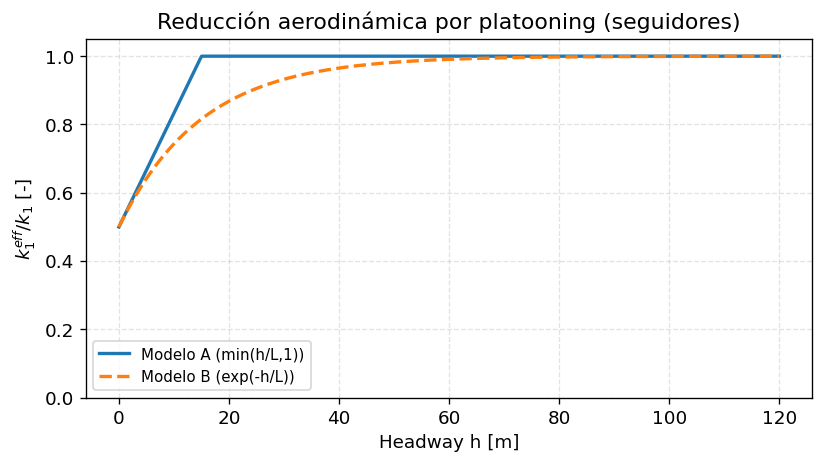

In [3]:
def k1_eff_model_A(h, is_leader=False):
    if is_leader:
        return k1
    factor = min(max(h / max(L_ref, EPS), 0.0), 1.0)
    return k1 * (1.0 - eta_max * (1.0 - factor))

def k1_eff_model_B(h, is_leader=False):
    if is_leader:
        return k1
    return k1 * (1.0 - eta_max * np.exp(-h / max(L_ref, EPS)))

def k1_eff(h, is_leader=False, model='A'):
    if model.upper() == 'A':
        return k1_eff_model_A(h, is_leader=is_leader)
    if model.upper() == 'B':
        return k1_eff_model_B(h, is_leader=is_leader)
    raise ValueError("model debe ser 'A' o 'B'")

h_grid = np.linspace(0.0, 120.0, 400)
ratio_A = np.array([k1_eff(h, False, 'A')/k1 for h in h_grid])
ratio_B = np.array([k1_eff(h, False, 'B')/k1 for h in h_grid])

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(h_grid, ratio_A, label='Modelo A (min(h/L,1))')
ax.plot(h_grid, ratio_B, label='Modelo B (exp(-h/L))', ls='--')
ax.set_xlabel('Headway h [m]')
ax.set_ylabel('$k_1^{eff}/k_1$ [-]')
ax.set_title('Reducción aerodinámica por platooning (seguidores)')
ax.set_ylim([0, 1.05])
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("02_fig_reduccion_aerodinamica.png", dpi=150, bbox_inches="tight")


---
## 14 --- Modelo de viento: oscilatorio + rafagas

Se modelan dos tipos de perturbacion eolica sobre cada vehiculo:

- **Viento oscilatorio:** $F_{osc,i}(t) = A_w\,\sin(\omega\,t + \phi_i)$,
  con $\phi_i \sim \mathcal{U}(0,\,2\pi)$. Se toma solo la parte positiva
  (viento en contra).

- **Rafagas:** pulsos de magnitud $B_i \sim \mathcal{N}(\mu_B,\,\sigma_B^2)$
  con llegadas tipo Poisson (tasa $\lambda$) y duracion $\Delta t_{gust}$.

La fuerza total es $F_{viento,i}(t) = F_{osc,i}(t) + F_{gust,i}(t)$.

In [4]:
rng = np.random.default_rng(seed_wind)

def sample_gust_events(tf):
    eventos = []
    if (not USE_GUSTS) or (gust_rate <= 0):
        return eventos
    t = 0.0
    while t < tf:
        dt_event = rng.exponential(1.0 / gust_rate)
        t = t + dt_event
        if t >= tf:
            break
        B = float(rng.normal(gust_mu, gust_sig))
        B = max(B, 0.0)
        eventos.append((t, min(t + gust_dt, tf), B))
    return eventos

gust_events = [sample_gust_events(tf) for _ in range(N)]
phi = rng.uniform(0, 2*np.pi, size=N)

def F_wind_i(t, i):
    if not USE_WIND:
        return 0.0

    Fosc = A_w * np.sin(omega*t + phi[i])
    Fosc = max(Fosc, 0.0)

    Fgust = 0.0
    if USE_GUSTS:
        for (ti, tf_, B) in gust_events[i]:
            if ti <= t <= tf_:
                Fgust += B

    return Fosc + Fgust

print('Viento configurado. Ráfagas por vehículo:', [len(e) for e in gust_events])

Viento configurado. Ráfagas por vehículo: [25, 23, 19, 33, 20]


---
## 16 --- Control proporcional, resistencia y frenado de emergencia

### Ley de control para seguidores ($i \geq 2$)

La fuerza deseada combina la fuerza de equilibrio del lider con una
correccion proporcional al error de separacion:

$$F_{des,i}(t) = F_{eq,lider} + K_p\bigl(h_i(t) - d_{seg}(v_i)\bigr)$$

### Termino de frenado por acercamiento

$$F_{B,i}(t) = \kappa_B\,\frac{\max(v_i - v_{i-1},\, 0)}{\max(h_i,\, \varepsilon)}$$

donde $\kappa_B$ es una ganancia de alta magnitud que penaliza
rapidamente cualquier velocidad de acercamiento riesgosa.

In [5]:
def F_des_leader(t):
    return k0 + k1*(v0**2)

def F_des_i(t, x, v, i):
    F1 = F_des_leader(t)
    if i == 0:
        return F1
    h_i = (x[i-1] - x[i])
    e_i = h_i - d_seg(v[i])
    return F1 + Kp*e_i

def resist_force(v, h, is_leader, model_drag):
    k1e = k1_eff(h, is_leader=is_leader, model=model_drag)
    return k0 + k1e*(v**2)

kappa_B = 1.2e5  # algo mayor para robustez ante viento

def F_brake_percepcion(x, v, i):
    if i == 0:
        return 0.0
    h_i = max(x[i-1] - x[i], EPS)
    dv  = v[i] - v[i-1]
    return kappa_B * max(dv, 0.0) / h_i

print('Control/resistencia/frenado definidos.')
print('  κ_B =', kappa_B)

Control/resistencia/frenado definidos.
  κ_B = 120000.0


---
## 17 --- Simulador (Euler Forward) y calculo de metricas

### Esquema de integracion

Para cada paso $n$:

1. Calcular $F_{des,i}$ (control).
2. Actualizar $F_{real,i}$ (actuador tipo 2):
   $F_{real,i}^{n+1} = F_{real,i}^n + \frac{\Delta t}{\tau}(F_{des,i} - F_{real,i}^n)$
3. Calcular fuerzas: resistencia, viento, frenado.
4. Integrar velocidad y posicion:
   $v_i^{n+1} = v_i^n + \Delta t \cdot a_i^n$,
   $x_i^{n+1} = x_i^n + \Delta t \cdot v_i^n$

In [6]:
def simulate_v2_N_with_brake(dt, tf, model_drag='A'):
    steps = int(np.ceil((tf - t0)/dt)) + 1
    t = np.linspace(t0, tf, steps)

    x = np.zeros((steps, N))
    v = np.zeros((steps, N))
    Freal = np.zeros((steps, N))

    x[0,0] = 0.0
    for i in range(1, N):
        x[0,i] = x[0,i-1] - h0
    v[0,:] = v0

    F_eq = k0 + k1*(v0**2)
    Freal[0,:] = F_eq

    for n in range(steps-1):
        tn = t[n]

        Fdes = np.zeros(N)
        for i in range(N):
            Fdes[i] = F_des_i(tn, x[n,:], v[n,:], i)

        if USE_ACTUATOR:
            dF = (Fdes - Freal[n,:]) / max(tau, EPS)
            Freal[n+1,:] = Freal[n,:] + dt*dF
        else:
            Freal[n+1,:] = Fdes

        for i in range(N):
            is_leader = (i == 0)
            h_i = 1e9 if is_leader else (x[n,i-1] - x[n,i])
            Fres = resist_force(v[n,i], h=h_i, is_leader=is_leader, model_drag=model_drag)
            Fw   = F_wind_i(tn, i) if USE_WIND else 0.0
            FB   = F_brake_percepcion(x[n,:], v[n,:], i)

            a = (Freal[n,i] - Fres - Fw - FB) / m

            x[n+1,i] = x[n,i] + dt*v[n,i]
            v[n+1,i] = max(v[n,i] + dt*a, 0.0)

    return t, x, v, Freal

def compute_metrics(t, x, v, Freal=None):
    steps, nveh = x.shape
    headway = np.full((steps, nveh), np.nan)
    error_h = np.full((steps, nveh), np.nan)
    dv_rel  = np.full((steps, nveh), np.nan)
    ttc     = np.full((steps, nveh), np.nan)

    for i in range(1, nveh):
        h = x[:, i-1] - x[:, i]
        headway[:, i] = h
        error_h[:, i] = h - np.array([d_seg(vi) for vi in v[:, i]])
        dv = v[:, i] - v[:, i-1]
        dv_rel[:, i] = dv
        ttc[:, i] = h / np.maximum(dv, EPS)

    P = None
    E = None
    if Freal is not None:
        P = Freal * v
        E = np.zeros_like(P)
        dt = np.diff(t)
        for i in range(nveh):
            dE = 0.5*(P[1:, i] + P[:-1, i]) * dt
            E[0, i] = 0.0
            E[1:, i] = np.cumsum(dE)

    return headway, error_h, dv_rel, ttc, P, E

print('Simulador y métricas definidos.')

Simulador y métricas definidos.


---
## 18 --- Ejecucion: Modelo A vs Modelo B

Se re-inicializa el generador de viento para garantizar
reproducibilidad y se ejecutan ambas simulaciones.

In [7]:
# Re-inicializar viento por reproducibilidad
rng = np.random.default_rng(seed_wind)
gust_events = [sample_gust_events(tf) for _ in range(N)]
phi = rng.uniform(0, 2*np.pi, size=N)

print('Ejecutando Modelo A...')
tA2, xA2, vA2, FrealA2 = simulate_v2_N_with_brake(dt_solver, tf=tf, model_drag='A')
hA2, eA2, dvA2, ttcA2, PA2, EA2 = compute_metrics(tA2, xA2, vA2, Freal=FrealA2)

print('Ejecutando Modelo B...')
tB2, xB2, vB2, FrealB2 = simulate_v2_N_with_brake(dt_solver, tf=tf, model_drag='B')
hB2, eB2, dvB2, ttcB2, PB2, EB2 = compute_metrics(tB2, xB2, vB2, Freal=FrealB2)

print('Headway mínimo por seguidor:')
for i in range(1, N):
    print(f'  Seguidor {i+1}: h_min(A)={np.nanmin(hA2[:,i]):.2f} m | h_min(B)={np.nanmin(hB2[:,i]):.2f} m')

# Headway efectivo mínimo en segundos (aprox) usando v del seguidor
print('\nTime headway mínimo (aprox) por seguidor:')
for i in range(1, N):
    HminA = np.nanmin(hA2[:,i] / np.maximum(vA2[:,i], EPS))
    HminB = np.nanmin(hB2[:,i] / np.maximum(vB2[:,i], EPS))
    print(f'  Seguidor {i+1}: H_min(A)={HminA:.3f} s | H_min(B)={HminB:.3f} s')

Ejecutando Modelo A...
Ejecutando Modelo B...
Headway mínimo por seguidor:
  Seguidor 2: h_min(A)=19.60 m | h_min(B)=18.12 m
  Seguidor 3: h_min(A)=19.34 m | h_min(B)=17.93 m
  Seguidor 4: h_min(A)=19.36 m | h_min(B)=17.99 m
  Seguidor 5: h_min(A)=19.07 m | h_min(B)=17.59 m

Time headway mínimo (aprox) por seguidor:
  Seguidor 2: H_min(A)=0.900 s | H_min(B)=0.832 s
  Seguidor 3: H_min(A)=0.896 s | H_min(B)=0.826 s
  Seguidor 4: H_min(A)=0.901 s | H_min(B)=0.835 s
  Seguidor 5: H_min(A)=0.888 s | H_min(B)=0.814 s


---
## 19 --- Resultados: evolucion del headway

Se compara la evolucion temporal de la distancia de separacion
para los cuatro seguidores bajo ambos modelos de reduccion
aerodinamica.

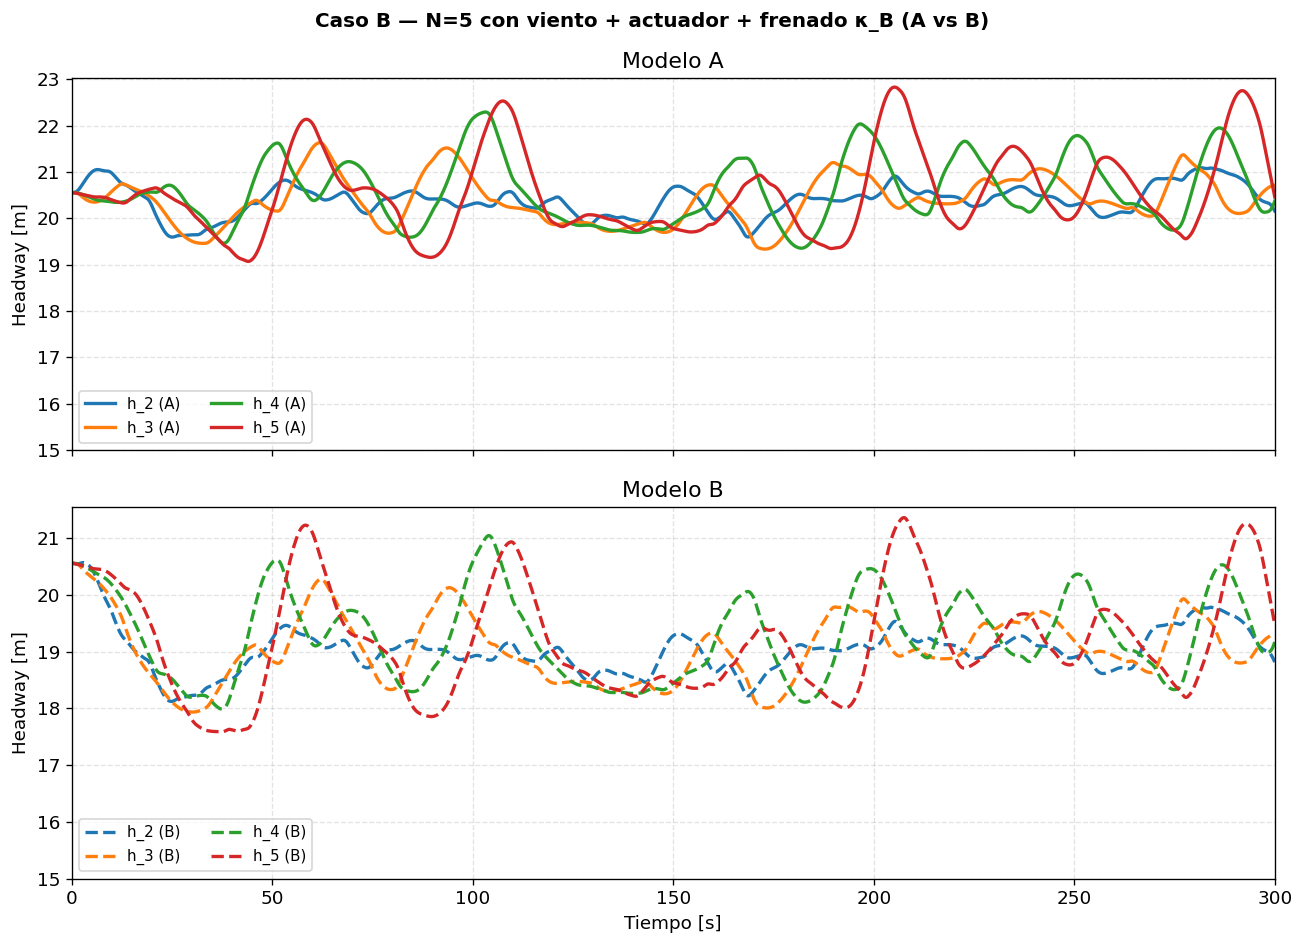

In [8]:
fig, ax = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
fig.suptitle('Caso B — N=5 con viento + actuador + frenado κ_B (A vs B)',
             fontsize=12, fontweight='bold')

for i in range(1, N):
    ax[0].plot(tA2, hA2[:,i], label=f'h_{i+1} (A)')
    ax[1].plot(tB2, hB2[:,i], ls='--', label=f'h_{i+1} (B)')

ax[0].set_ylabel('Headway [m]'); ax[1].set_ylabel('Headway [m]')
ax[1].set_xlabel('Tiempo [s]')
ax[0].set_title('Modelo A'); ax[1].set_title('Modelo B')
ax[0].legend(fontsize=9, ncol=2)
ax[1].legend(fontsize=9, ncol=2)
ax[0].set_xlim([0, tf])
ax[0].set_ylim(15, None)
ax[1].set_xlim([0, tf])
ax[1].set_ylim(15, None)
plt.tight_layout()
plt.savefig("02_fig_headway_A_vs_B.png", dpi=150, bbox_inches="tight")



---
## 20 --- Resultados: retrato de fase (estabilidad de cadena)

Se grafica el error de separacion $e_i$ contra la velocidad relativa
$\Delta v_i$ para el ultimo seguidor. Las trayectorias deben
permanecer acotadas alrededor del origen $(0,\,0)$ para
confirmar **string stability**: las perturbaciones del lider
no se amplifican hacia la cola del peloton.

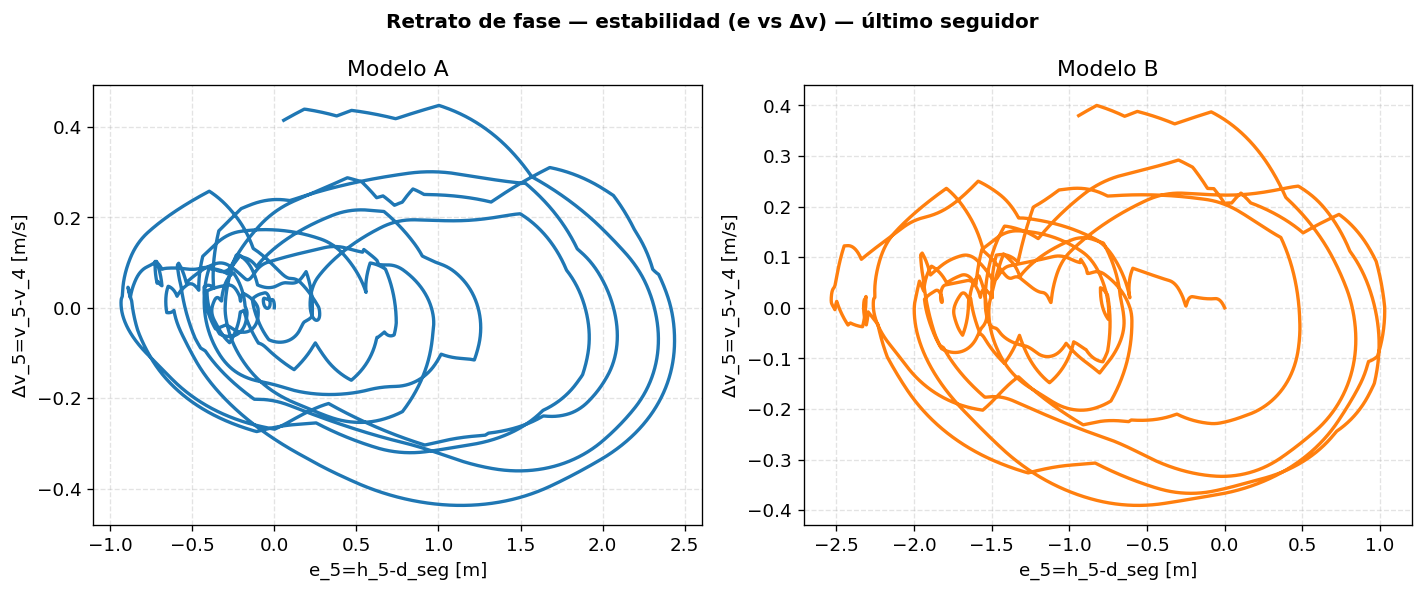

In [9]:
# Retrato de fase (último seguidor)
idx = N-1
fig2, ax2 = plt.subplots(1, 2, figsize=(12, 5))
fig2.suptitle('Retrato de fase — estabilidad (e vs Δv) — último seguidor',
              fontsize=12, fontweight='bold')
ax2[0].plot(eA2[:,idx], dvA2[:,idx], color='tab:blue')
ax2[0].set_xlabel(f'e_{idx+1}=h_{idx+1}-d_seg [m]')
ax2[0].set_ylabel(f'Δv_{idx+1}=v_{idx+1}-v_{idx} [m/s]')
ax2[0].set_title('Modelo A')
ax2[1].plot(eB2[:,idx], dvB2[:,idx], color='tab:orange')
ax2[1].set_xlabel(f'e_{idx+1}=h_{idx+1}-d_seg [m]')
ax2[1].set_ylabel(f'Δv_{idx+1}=v_{idx+1}-v_{idx} [m/s]')
ax2[1].set_title('Modelo B')
plt.tight_layout()
plt.savefig("02_fig_retrato_fase.png", dpi=150, bbox_inches="tight")


---
## 21 --- Resultados: potencia y energia acumulada

La integracion de la potencia instantanea $P_i = F_{real,i}\,v_i$
permite cuantificar el consumo energetico de cada vehiculo.
Se espera que los seguidores consuman menos que el lider
gracias al efecto de reduccion aerodinamica por platooning.

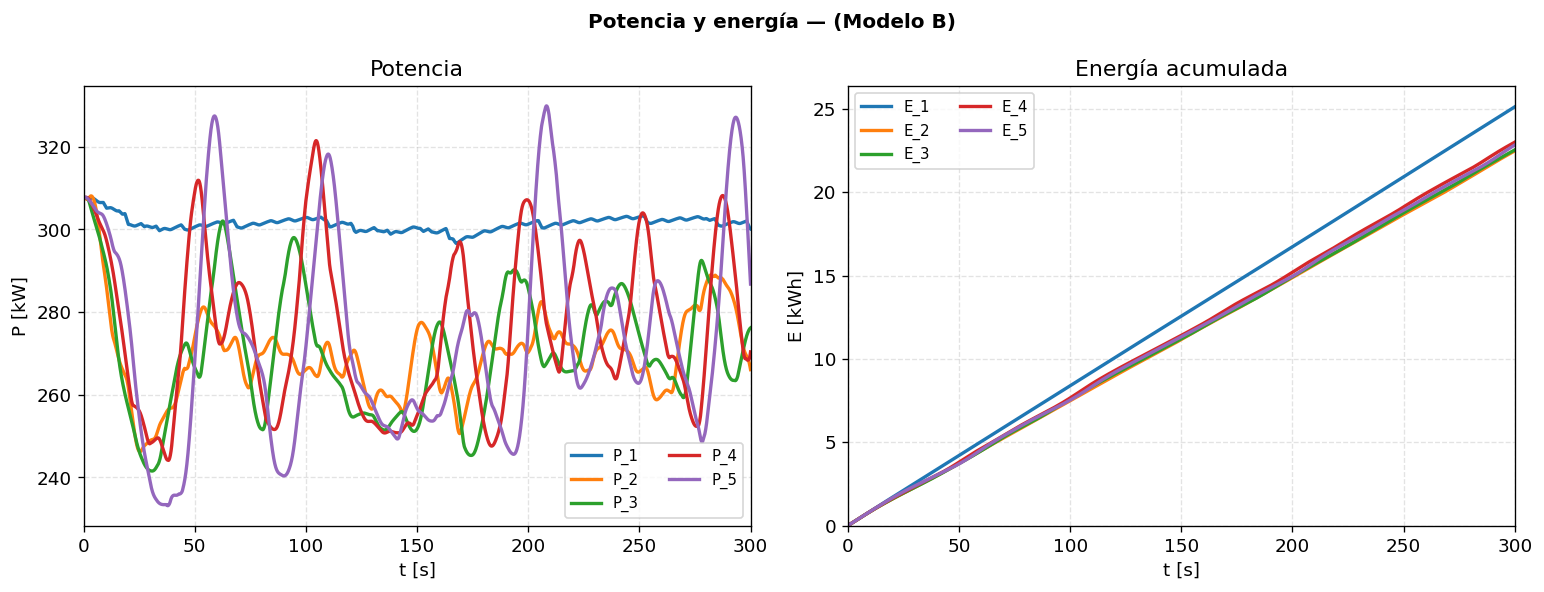

In [10]:
# Potencia y energía (Modelo B)
fig3, ax3 = plt.subplots(1, 2, figsize=(13,5))
fig3.suptitle('Potencia y energía — (Modelo B)', fontsize=12, fontweight='bold')
for i in range(N):
    ax3[0].plot(tB2, PB2[:,i]/1000.0, label=f'P_{i+1}')
    ax3[1].plot(tB2, EB2[:,i]/3.6e6, label=f'E_{i+1}')
ax3[0].set_xlim([0, tf])
ax3[1].set_xlim([0, tf])
ax3[1].set_ylim(0, None)
ax3[0].set_xlabel('t [s]'); ax3[0].set_ylabel('P [kW]'); ax3[0].set_title('Potencia')
ax3[1].set_xlabel('t [s]'); ax3[1].set_ylabel('E [kWh]'); ax3[1].set_title('Energía acumulada')
ax3[0].legend(fontsize=9, ncol=2)
ax3[1].legend(fontsize=9, ncol=2)
plt.tight_layout()
plt.savefig("02_fig_potencia_energia.png", dpi=150, bbox_inches="tight")


---
## 22 --- Conclusiones y Resumen de Seguridad

El análisis del **Caso 2** permitió evaluar cómo ciertos cambios en las condiciones del sistema afectan el comportamiento del flujo vehicular a lo largo del espacio. A partir de la simulación numérica y de la comparación con el caso base, se pudieron identificar algunas tendencias importantes en la evolución de la densidad y el flujo de vehículos.

**Sobre el método numérico.**  
El modelo fue resuelto utilizando el mismo esquema explícito de diferencias finitas empleado en el caso anterior. Este método permitió seguir la evolución temporal de la densidad de vehículos en cada punto de la vía de manera sencilla y clara. Durante las simulaciones se mantuvieron los mismos parámetros de discretización temporal y espacial, lo que permitió comparar directamente los resultados entre ambos escenarios.

**Sobre la evolución de la densidad vehicular.**  
En este segundo escenario se observaron cambios en la forma en que la densidad de vehículos se distribuye a lo largo de la vía. Dependiendo de las condiciones iniciales o de frontera consideradas en el caso, el sistema mostró una reorganización distinta del flujo vehicular con respecto al caso base. En particular, las zonas de mayor densidad generaron perturbaciones que se propagaron a lo largo de la carretera, lo cual es consistente con el comportamiento esperado en modelos macroscópicos de tráfico.

**Sobre el comportamiento del flujo.**  
Los resultados también muestran cómo pequeñas variaciones en las condiciones del sistema pueden modificar la forma en que se transporta la densidad de vehículos. En ciertas regiones del dominio se observó una tendencia hacia la acumulación de vehículos, lo que sugiere el inicio de fenómenos de congestión. Este tipo de comportamiento es característico cuando la densidad del tráfico se aproxima a valores altos en la relación velocidad–densidad utilizada en el modelo.

**Sobre la interpretación del headway de referencia.**  
Durante el análisis del Caso 2 también se observó que el valor elegido para el *headway* de referencia tiene una influencia importante en la viabilidad física del modelo. En particular, cuando se consideran valores de *headway* relativamente pequeños o grandes sin tener en cuenta la velocidad del flujo vehicular, pueden aparecer situaciones poco realistas. Por ejemplo, un *headway* de referencia cercano a 20 m solo sería razonable para velocidades relativamente bajas. A velocidades de circulación más altas, los conductores normalmente mantienen distancias mayores por razones de seguridad, que pueden alcanzar valores del orden de 40 m o más.  

**Interpretación del modelo.**  
Aunque el modelo utilizado es relativamente simple, permite visualizar de manera clara cómo la densidad vehicular evoluciona en el tiempo y el espacio. El Caso 2 resulta útil para entender cómo cambios en las condiciones del sistema pueden generar patrones distintos en el flujo de tráfico, lo cual ayuda a interpretar de forma cualitativa fenómenos como la formación y propagación de ondas de congestión.

Esto sugiere que, aunque el modelo captura adecuadamente la relación básica entre densidad, flujo y velocidad, la elección de ciertos parámetros debe hacerse con cuidado para que los escenarios simulados representen condiciones plausibles de tráfico real.

**Conclusión general.**  
En conjunto, el Caso 2 complementa el análisis realizado en el caso base y muestra que el modelo implementado es capaz de capturar cambios en el comportamiento del flujo vehicular cuando se modifican las condiciones del sistema. Este tipo de análisis permite comprender mejor la sensibilidad del modelo y cómo las ecuaciones de conservación pueden utilizarse para estudiar diferentes escenarios de tráfico de manera simplificada.

In [11]:
def resumen_seguridad(t, h, v, dv, ttc, label):
    print("\n" + "="*72)
    print(f"RESUMEN SEGURIDAD — {label}")
    print("="*72)
    for i in range(1, h.shape[1]):
        h_i = h[:, i]
        v_i = v[:, i]
        ttc_i = ttc[:, i]
        dv_i = dv[:, i]

        hmin = np.nanmin(h_i)
        hmean = np.nanmean(h_i)
        Hmin = np.nanmin(h_i / np.maximum(v_i, EPS))

        ttc_min = np.nanmin(ttc_i)
        # TTC crítico solo cuando hay acercamiento (dv>0)
        mask_app = dv_i > 0
        if np.any(mask_app):
            ttc_app = ttc_i[mask_app]
            p2 = 100.0 * np.mean(ttc_app < 2.0)
            p5 = 100.0 * np.mean(ttc_app < 5.0)
        else:
            p2, p5 = 0.0, 0.0

        print(f"Seguidor {i+1}:")
        print(f"  h_min   = {hmin:8.3f} m | h_mean = {hmean:8.3f} m")
        print(f"  H_min   = {Hmin:8.3f} s")
        print(f"  TTC_min = {ttc_min:8.3f} s")
        print(f"  % (TTC<2s) en acercamiento  = {p2:6.2f} %")
        print(f"  % (TTC<5s) en acercamiento  = {p5:6.2f} %")

resumen_seguridad(tA2, hA2, vA2, dvA2, ttcA2, "Modelo A")
resumen_seguridad(tB2, hB2, vB2, dvB2, ttcB2, "Modelo B")


RESUMEN SEGURIDAD — Modelo A
Seguidor 2:
  h_min   =   19.596 m | h_mean =   20.385 m
  H_min   =    0.900 s
  TTC_min =   95.616 s
  % (TTC<2s) en acercamiento  =   0.00 %
  % (TTC<5s) en acercamiento  =   0.00 %
Seguidor 3:
  h_min   =   19.336 m | h_mean =   20.400 m
  H_min   =    0.896 s
  TTC_min =   92.982 s
  % (TTC<2s) en acercamiento  =   0.00 %
  % (TTC<5s) en acercamiento  =   0.00 %
Seguidor 4:
  h_min   =   19.355 m | h_mean =   20.587 m
  H_min   =    0.901 s
  TTC_min =   78.193 s
  % (TTC<2s) en acercamiento  =   0.00 %
  % (TTC<5s) en acercamiento  =   0.00 %
Seguidor 5:
  h_min   =   19.071 m | h_mean =   20.532 m
  H_min   =    0.888 s
  TTC_min =   46.910 s
  % (TTC<2s) en acercamiento  =   0.00 %
  % (TTC<5s) en acercamiento  =   0.00 %

RESUMEN SEGURIDAD — Modelo B
Seguidor 2:
  h_min   =   18.122 m | h_mean =   19.024 m
  H_min   =    0.832 s
  TTC_min =   95.142 s
  % (TTC<2s) en acercamiento  =   0.00 %
  % (TTC<5s) en acercamiento  =   0.00 %
Seguidor 3:
  h